In [1]:
import pandas as pd

def load_electricitymaps(filepath, region_name):
    df = pd.read_csv(filepath)
    df["datetime"] = pd.to_datetime(df["Datetime (UTC)"])
    df = df[["datetime",
             "Carbon intensity gCO₂eq/kWh (direct)",
             "Carbon-free energy percentage (CFE%)",
             "Renewable energy percentage (RE%)"]]
    df.columns = ["datetime", "carbon_intensity", "cfe_pct", "re_pct"]
    df["region"] = region_name
    return df

def load_openmeteo(filepath):
    df = pd.read_csv(filepath, skiprows=3)
    df["datetime"] = pd.to_datetime(df["time"])
    df = df[["datetime",
             "temperature_2m (°C)",
             "wind_speed_10m (km/h)",
             "cloud_cover (%)",
             "shortwave_radiation (W/m²)"]]
    df.columns = ["datetime", "temp_c", "wind_speed", "cloud_cover", "solar_radiation"]
    return df

# load ElectricityMaps
em_california = load_electricitymaps("snapshots_2026-02-10_US-CAL-CISO-2023-hourly.csv", "california")
em_texas      = load_electricitymaps("snapshots_2026-02-10_US-TEX-ERCO-2023-hourly.csv", "texas")
em_illinois   = load_electricitymaps("snapshots_2026-02-10_US-MIDW-MISO-2023-hourly.csv", "illinois")
em_virginia   = load_electricitymaps("snapshots_2026-02-10_US-MIDA-PJM-2023-hourly.csv", "virginia")

# load Open-Meteo
wx_california = load_openmeteo("open-meteo-california.csv")
wx_texas      = load_openmeteo("open-meteo-texas.csv")
wx_illinois   = load_openmeteo("open-meteo-illinois.csv")
wx_virginia   = load_openmeteo("open-meteo-virginia.csv")

# merge each region
def merge_region(em, wx):
    return pd.merge(em, wx, on="datetime", how="inner")

california = merge_region(em_california, wx_california)
texas      = merge_region(em_texas,      wx_texas)
illinois   = merge_region(em_illinois,   wx_illinois)
virginia   = merge_region(em_virginia,   wx_virginia)

# stack all regions
df = pd.concat([california, texas, illinois, virginia], ignore_index=True)

# add time features
df["hour"]        = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"]       = df["datetime"].dt.month


print("Shape:", df.shape)
print("Rows per region:\n", df["region"].value_counts())
print("Null counts:\n", df.isnull().sum())

# save
df.to_csv("merged_dataset.csv", index=False)
print("Saved to merged_dataset.csv")

Shape: (35040, 12)
Rows per region:
 region
california    8760
texas         8760
illinois      8760
virginia      8760
Name: count, dtype: int64
Null counts:
 datetime            0
carbon_intensity    0
cfe_pct             0
re_pct              0
region              0
temp_c              0
wind_speed          0
cloud_cover         0
solar_radiation     0
hour                0
day_of_week         0
month               0
dtype: int64
Saved to merged_dataset.csv


#EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the merged dataset
df = pd.read_csv("merged_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nBasic stats:\n", df[["carbon_intensity", "temp_c", "wind_speed",
                               "cloud_cover", "solar_radiation"]].describe())

Shape: (35040, 12)

Column types:
 datetime            datetime64[ns]
carbon_intensity           float64
cfe_pct                    float64
re_pct                     float64
region                      object
temp_c                     float64
wind_speed                 float64
cloud_cover                  int64
solar_radiation            float64
hour                         int64
day_of_week                  int64
month                        int64
dtype: object

Basic stats:
        carbon_intensity        temp_c    wind_speed   cloud_cover  \
count      35040.000000  35040.000000  35040.000000  35040.000000   
mean         318.059603     15.766664     14.183028     52.391638   
std          102.926575      8.969408      7.802388     44.101126   
min           53.190000    -19.500000      0.000000      0.000000   
25%          252.837500      9.400000      8.200000      1.000000   
50%          322.395000     15.700000     13.200000     55.000000   
75%          385.380000     22.00

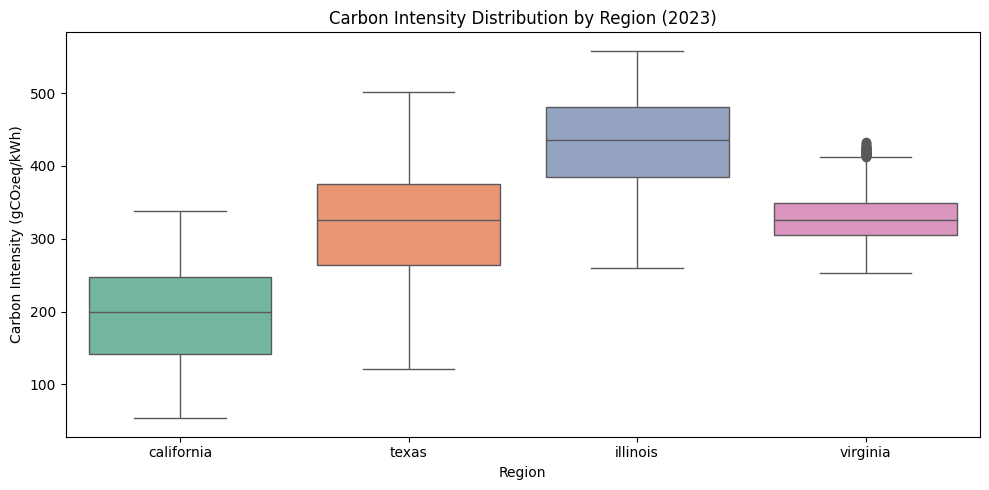

In [8]:
# Carbon intensity by region (boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="region", y="carbon_intensity",
            order=["california", "texas", "illinois", "virginia"],
            hue="region", palette="Set2", legend=False)
plt.title("Carbon Intensity Distribution by Region (2023)")
plt.xlabel("Region")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.tight_layout()
plt.savefig("01_boxplot_by_region.png", dpi=150)
plt.show()

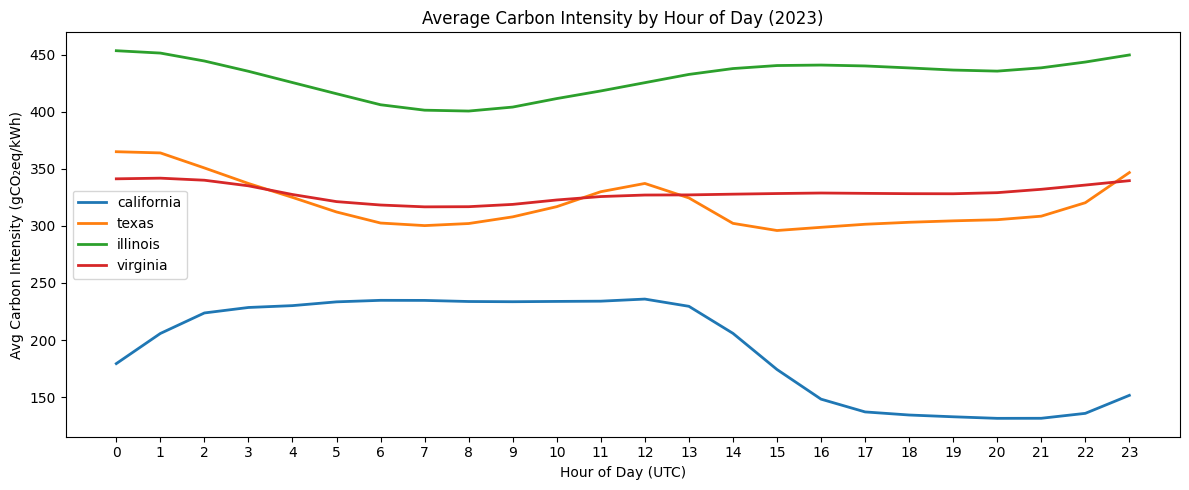

In [4]:
#  Average carbon intensity by hour of day
hourly = df.groupby(["region", "hour"])["carbon_intensity"].mean().reset_index()

plt.figure(figsize=(12, 5))
for region in ["california", "texas", "illinois", "virginia"]:
    subset = hourly[hourly["region"] == region]
    plt.plot(subset["hour"], subset["carbon_intensity"], label=region, linewidth=2)

plt.title("Average Carbon Intensity by Hour of Day (2023)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Avg Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("02_hourly_pattern.png", dpi=150)
plt.show()

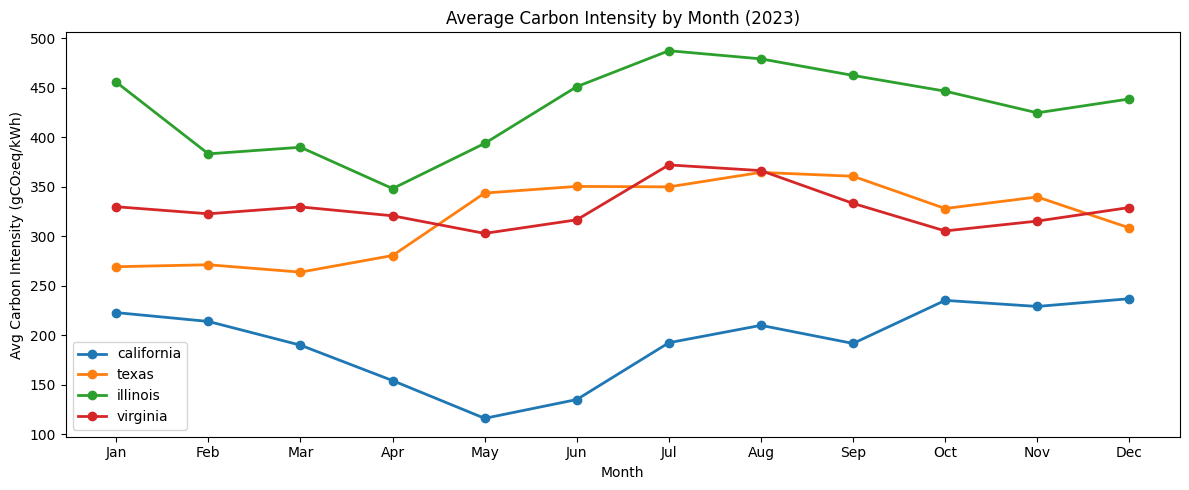

In [5]:
# Average carbon intensity by month
monthly = df.groupby(["region", "month"])["carbon_intensity"].mean().reset_index()

plt.figure(figsize=(12, 5))
for region in ["california", "texas", "illinois", "virginia"]:
    subset = monthly[monthly["region"] == region]
    plt.plot(subset["month"], subset["carbon_intensity"], label=region,
             linewidth=2, marker="o")

plt.title("Average Carbon Intensity by Month (2023)")
plt.xlabel("Month")
plt.ylabel("Avg Carbon Intensity (gCO₂eq/kWh)")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.legend()
plt.tight_layout()
plt.savefig("03_monthly_pattern.png", dpi=150)
plt.show()

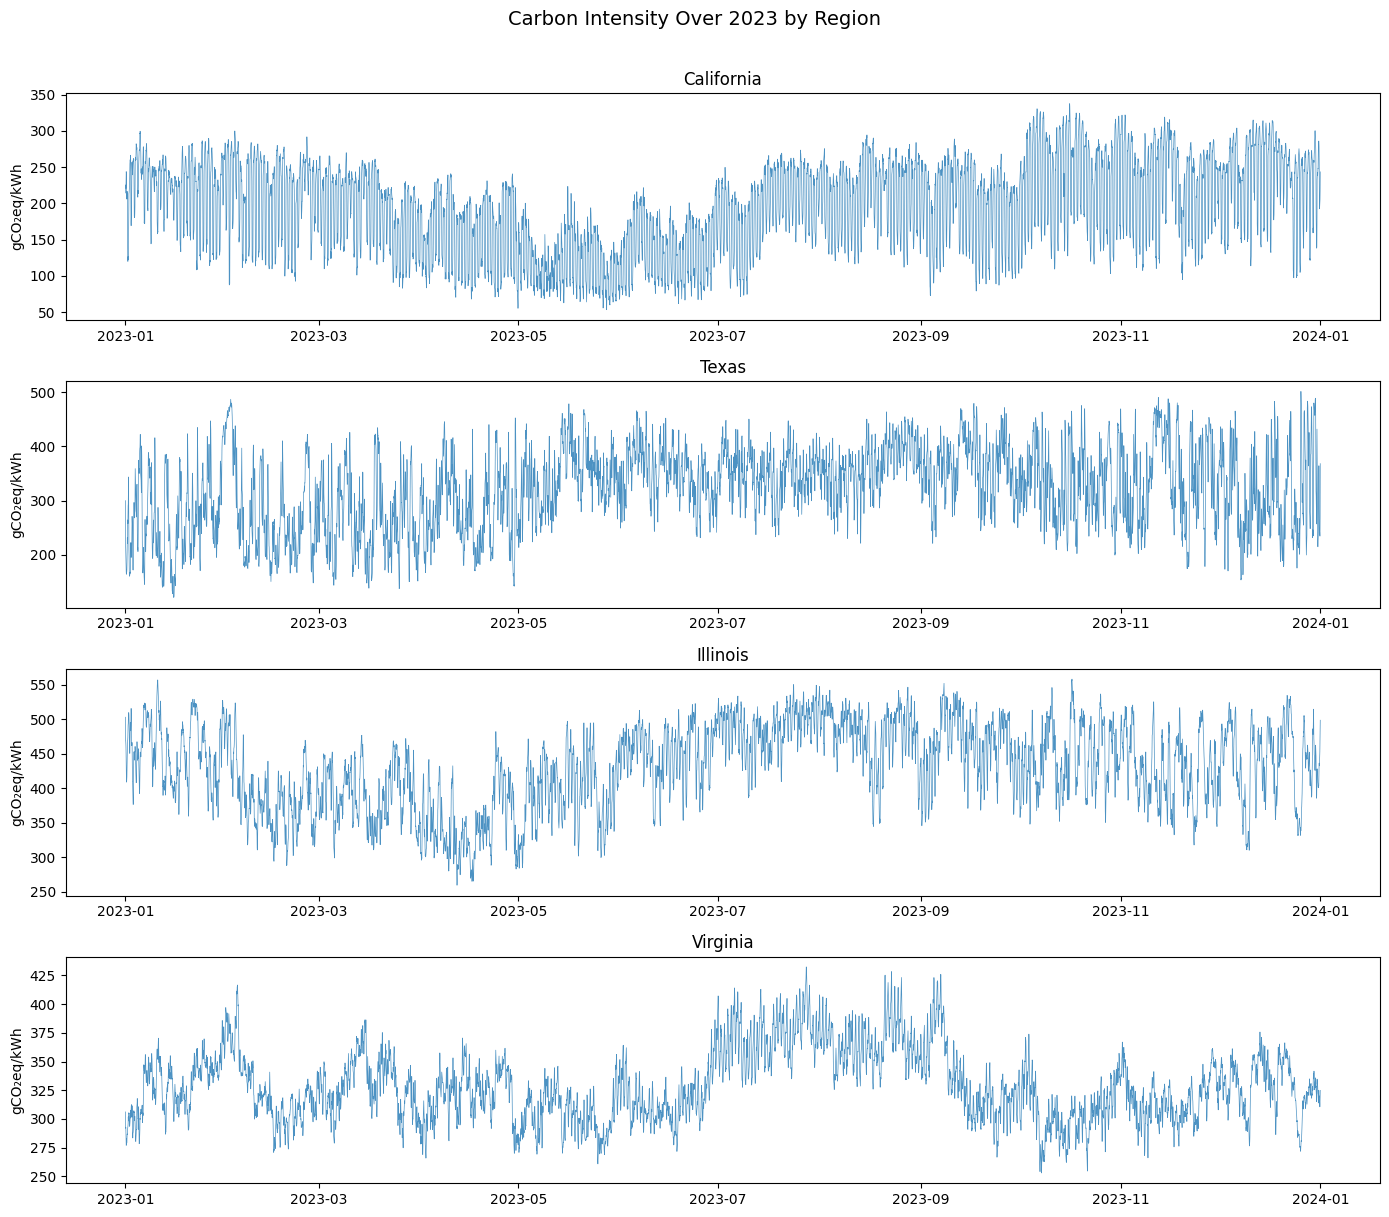

In [6]:
#full year time series per region
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
regions = ["california", "texas", "illinois", "virginia"]

for ax, region in zip(axes, regions):
    subset = df[df["region"] == region]
    ax.plot(subset["datetime"], subset["carbon_intensity"],
            linewidth=0.5, alpha=0.8)
    ax.set_title(f"{region.capitalize()}")
    ax.set_ylabel("gCO₂eq/kWh")

plt.suptitle("Carbon Intensity Over 2023 by Region", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("04_timeseries.png", dpi=150)
plt.show()

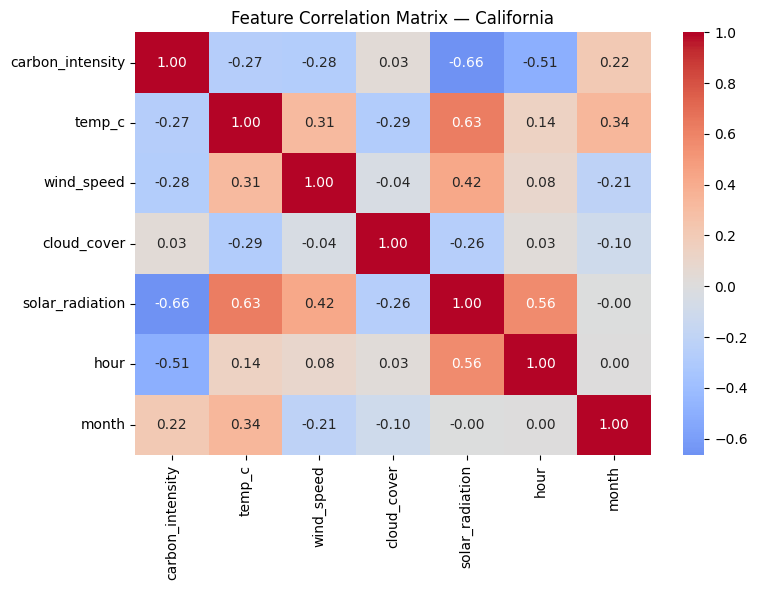

In [7]:
# correlation heatmap (California example)
ca = df[df["region"] == "california"][["carbon_intensity", "temp_c",
                                        "wind_speed", "cloud_cover",
                                        "solar_radiation", "hour",
                                        "month"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(ca, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix — California")
plt.tight_layout()
plt.savefig("05_correlation_heatmap.png", dpi=150)
plt.show()